# Part 2 — Displacement fields to a restoring flow (LDI) Example 2

This example takes observations from a deformed (folded) layer, including points along layer surfaces and normal-vectors describing the orientation of these surfaces.

In this case, the fold is "recumbent", similar to taking sheets of paper and folding them in half. This presents significant challenges as large deformations are required to reach this geometry, and conventional interpolators struggle to fit the observations as a single surface / sheet.

In the following we use neural fields to undo this folding. First, a neural field is parameterised that tries to directly predict the displacement. Them, we explore learnable diffeomorphic fields than attempt the same, but using a learned velocity field that lets us include physical constraints (e.g., that the material is incompressible throughout the deformation) on the solution. 

## Notebook outline

1. Load and plot our constraints
2. Learning displacement
3. All about that Jacobian...
4. Adding in the physics through learnable diffeomorphisms
5. RK4 integral of the velocity


## Step 0 — Setup

First we need to get everything setup, as in the previous example. Run the notebook with the working directory set to the workshop folder.

On Colab, run the next cell first. It clones the workshop repository (set `WORKSHOP_REPO` to the GitHub URL) so `ldi.py` and `data/` are on the runtime, and installs `svgpathtools`. Locally, start the notebook from the workshop folder instead.


In [1]:
# Running in Colab? Clone the workshop repo so ldi.py and the data files are on the runtime.
try:
    import google.colab  # present only inside a Colab runtime
    IN_COLAB = True
except ImportError:
    IN_COLAB = False  # local Jupyter or Cursor

WORKSHOP_REPO = ""  # e.g. "https://github.com/<org>/<repo>.git"

if IN_COLAB:
    import os
    import shutil
    import subprocess
    import sys
    from pathlib import Path

    if not WORKSHOP_REPO:
        raise RuntimeError(
            "Set WORKSHOP_REPO to the workshop GitHub URL before running on Colab."
        )
    dest = Path("/content/workshop")  # Colab's local disk
    needed = dest / "data/model3_surface_points.csv"  # this notebook's data file
    if not (dest / "ldi.py").exists() or not needed.exists():
        if dest.exists():
            shutil.rmtree(dest)  # incomplete checkout cannot be cloned into
        # shallow clone: notebooks, ldi.py, and data/
        subprocess.check_call(["git", "clone", "--depth", "1", WORKSHOP_REPO, str(dest)])
    if not needed.exists():
        raise FileNotFoundError(f"Clone succeeded but {needed} is missing.")
    os.chdir(dest)  # later cells take Path.cwd() as the workshop root
    # svgpathtools is not on the Colab image; numpy, torch, matplotlib, and tqdm are
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "svgpathtools"])
    print("Colab: using", dest.resolve())
else:
    print("Not running in Colab; using the local workshop folder.")


Not running in Colab; using the local workshop folder.


In [2]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import torch

HERE = Path.cwd().resolve()
if not (HERE / "ldi.py").exists():
    raise RuntimeError(
        "Run this notebook from the workshop folder (the directory that contains ldi.py)."
    )
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from ldi import (
    DisplacementField,
    EulerVelocity,
    RestoringFlow,
    depth_std,
    grid_axes,
    length_scales_for,
    load_recumbent_fold,
    plot_constraints,
    plot_determinants,
    plot_history,
    plot_scalar,
    plot_traces,
    plot_velocity,
    plot_warps,
    summarise_restoration,
    velocity_snapshot,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("workshop:", HERE)
print("device:", device)


workshop: /Users/kamath92/Documents/Work/2026/DevOps/AISymposium/PhysInArch_HZDRAI
device: cpu


## Step 1 — Load and plot our constraints

Next we need data. This data takes two forms: contact points specifying positions on the surface of our layers, and normal vectors specifying their orientation.

curves: 2  (Younger horizon, Older horizon)
unit normals: 2
  curve 0: 10 fit points, 10 on the full polyline
  curve 1: 11 fit points, 11 on the full polyline
section width: 700.0
wavelength band: 600.0 – 3000.0
unit normals:
  (-21.7, +280.0)  n=(-0.100, -0.995)
  (-21.7, -280.0)  n=(-0.100, +0.995)


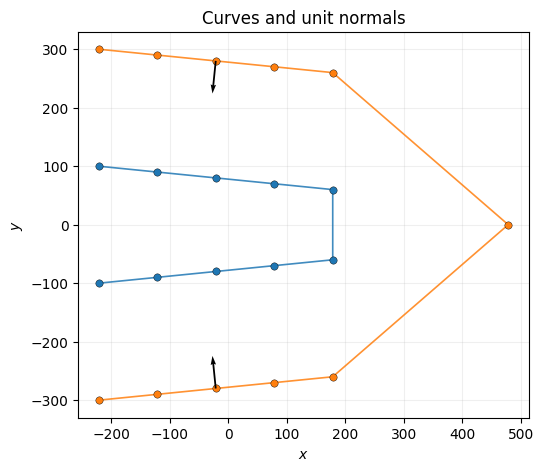

In [17]:
SURFACE = HERE / "data" / "model3_surface_points.csv"
ORIENTATIONS = HERE / "data" / "model3_orientations.csv"
data = load_recumbent_fold(SURFACE, ORIENTATIONS, section_y=500.0)

LSR = (600., 3000.)
N_FEATURES = 128
N_STEPS = 8
EPOCHS = 250
N_IQ = 8
xs, ys = grid_axes(data)

print(f"curves: {len(data.horizons)}  ({', '.join(data.names)})")
print(f"unit normals: {data.gp.shape[0]}")
for i, (sparse, full) in enumerate(zip(data.horizons, data.horizons_full)):
    print(f"  curve {i}: {len(sparse)} fit points, {len(full)} on the full polyline")
print(f"section width: {data.extent:.1f}")
print(f"wavelength band: {LSR[0]:.1f} – {LSR[1]:.1f}")
print("unit normals:")
for point, normal in zip(data.gp, data.gv):
    print(f"  ({point[0]:+.1f}, {point[1]:+.1f})  n=({normal[0]:+.3f}, {normal[1]:+.3f})")
plot_constraints(data, title="Curves and unit normals")


---------------

**Question 1**: These normals are measured in the observed coordinates. In the reference state they should all point straight up. What loss can be built from them, and how much of the displacement does it actually constrain? One of the two normals points downward: what does the loss ask of the Jacobian there?

**Answer**: In the reference state the level sets are horizontal, so the reference normal is $e_y$. The map carries that vector into the observed coordinates by the Jacobian, $\nabla\varphi = (I + Du)^T e_y$. A loss can penalise the angle between this transported vector and the measured unit normal. At the upward normal that asks for a modest rotation. At the downward normal it asks the Jacobian to turn $e_y$ past vertical. Flatness does not. Either way the loss constrains the local linear part of $u$ at those two locations only, not the displacement itself. Sliding a point along the curve leaves the normal unchanged, and between the two locations $u$ is whatever the Fourier features interpolate.

---------------


## Step 2 — Learning displacement

Now the fun begins :-)

As described above, we know that the observed geometry is the product of some deformation that transformed flat/horizontal layers into the folded / crumpled sheets seen today. 

Below we parameterise a neural field that tries to learn displacement vectors that directly represent this deformation. A Fourier neural field is constructed to predict three outputs `dx, dy, dz` at each point in space. These displacements can be applied to move everything back into the original simple/planar coordinate system in which our layers/sheets are simply isosurfaces of `y=constant`.


In [18]:
field = DisplacementField(
    num_fourier_features=32,
    length_scales=LSR,
    hidden_layers=[128, 128],
    depth_axis=1,
    seed=1,
    device=device,
)
history = field.fit(
    data,
    epochs=EPOCHS,
    lr=1e-2,
    n_iq=N_IQ,
    patience=40,
    verbose=True,
)
print("frozen loss scales:", {k: f"{v:.3e}" for k, v in field.scales.items()})
print("epochs kept:", len(history))


displacement: 100%|██████████| 250/250 [00:00<00:00, 482.19it/s, eq=0.000272, grad=1.44e-06, iq=0, total=0.000274]

frozen loss scales: {'grad': '2.160e+00', 'eq': '2.562e-05', 'iq': '2.063e-05'}
epochs kept: 250


Check how our loss looks:

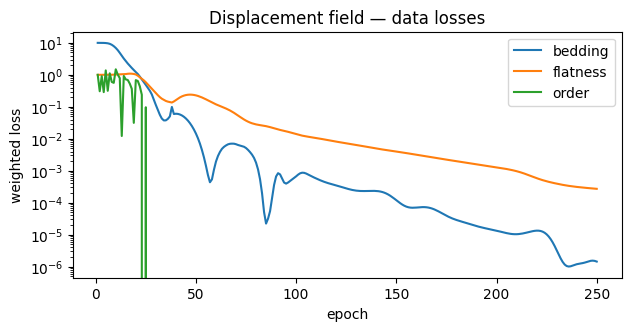

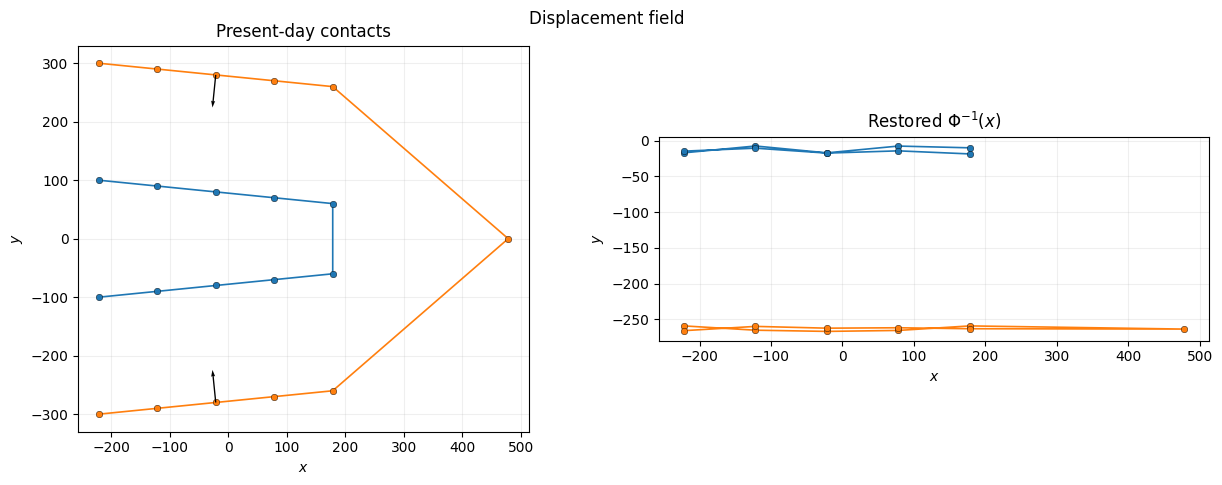

restored-depth std   sparse 3.316    full traces 3.316
  curve 0 (Younger horizon)  std φ = 4.013
  curve 1 (Older horizon)  std φ = 2.620


In [19]:
plot_history(history)
plot_traces(data, field.inverse_map, title="Displacement field")
sparse = depth_std(field.inverse_map, data.horizons)
full = depth_std(field.inverse_map, data.horizons_full)
print(f"restored-depth std   sparse {sparse.mean():.3f}    full traces {full.mean():.3f}")
for i, spread in enumerate(full):
    print(f"  curve {i} ({data.names[i]})  std φ = {spread:.3f}")


## Step 3 — All about that Jacobian...

A small data loss does not mean the map is a plausible deformation. Rocks (and many other materials) are basically incompressible, requiring area to be preserved when they are deformed. 

We can check for area change using the Jacobian of our neural field: positive jacobian means stretching of the material, while negative values indicate shrinking or collapse. 

displacement
  restored-depth std   sparse 3.316    full traces 3.316
    horizon 0 (Younger horizon)  std φ = 4.013
    horizon 1 (Older horizon)  std φ = 2.620
  det J   min -4.1362   max 2.2560   mean |det J - 1| 1.216e+00   max |det J - 1| 5.136e+00   fraction det J < 0  0.422


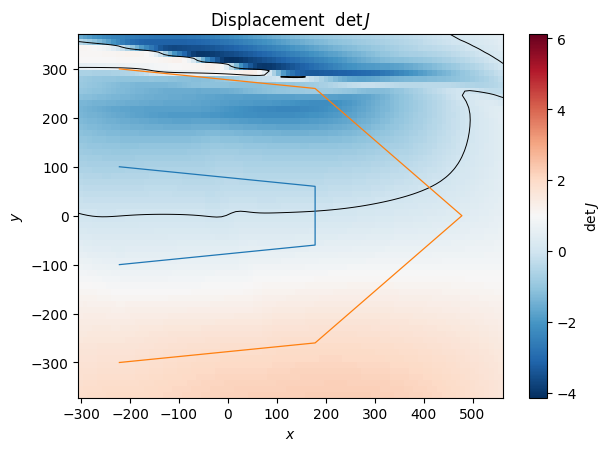

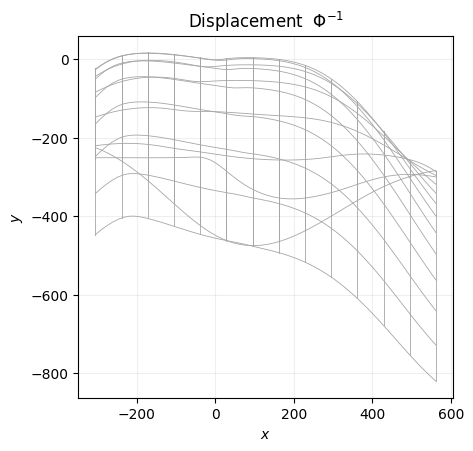

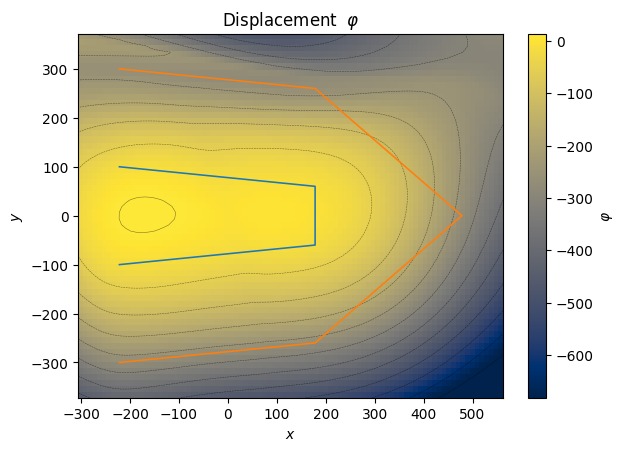

In [20]:
det_disp = summarise_restoration(
    "displacement", field.inverse_map, field.jacobian, data, xs, ys
)["det"]
plot_determinants(xs, ys, [("Displacement  $\det J$", det_disp)], data)
plot_warps(xs, ys, [("Displacement  $\Phi^{-1}$", field.inverse_map)])
plot_scalar(
    xs,
    ys,
    [(r"Displacement  $\varphi$", field.inverse_map)],
    data,
)


---------------

**Question 2**: Our loss scores the flatness $\varphi$ and original horizontallity $\nabla \varphi$ of the sample points. Between those points the displacement is filled in by the Fourier features. What can that interpolant do to the area of a patch, or to the order of two neighbouring patches, while both losses stay small? Is the learned map volume-preserving? Can material "cross itself" / self-intersect when being transported from observed to undeformed coordinates?

**Answer**: The field can stretch, squash it, or fold the material however it likes, so that $\det(I + Du)$ passes through zero and becomes negative. Neighbouring patches can cross or swap order wherever the map stops being injective. Nothing in the loss reads $\det J$, so the map is not volume-preserving, and a tangled image is a perfectly legal minimiser.

---------------

## Step 4 — Adding in the physics through learnable diffeomorphisms

The displacement field can change area and cause self-intersections because nothing in its construction forbids it. 

Now we parameterise a new neural field that includes our physical constraints: no self-intersections (i.e. the displacement must be a diffeomorphism of the original layer-cake topology), and volume preservation as we assume the material is incompressible. 

This is achieved through `EulerVelocity`, which stores one Fourier potential representing a stream function:

$$\alpha(x) = \frac{s}{\sqrt{F}} \sum_k \frac{A_k \cos(k\cdot x) + B_k \sin(k\cdot x)}{|k|^{2}}$$

The velocity is the gradient of this stream function rotated by 90 degrees (in 2D this can be generalised to e.g., a Clebsch formulation involving the cross product of gradients of two fields).

This vector field by definition has no divergence, so represents a physically plausible velocity field for an incompressible fluid/material. Now we just need to find a velocity field that, after displacing our input coordinates backwards through it to some time t=-1, yields the desired layer-cake undeformed geometry.

|v| max 0    |div v| max 0


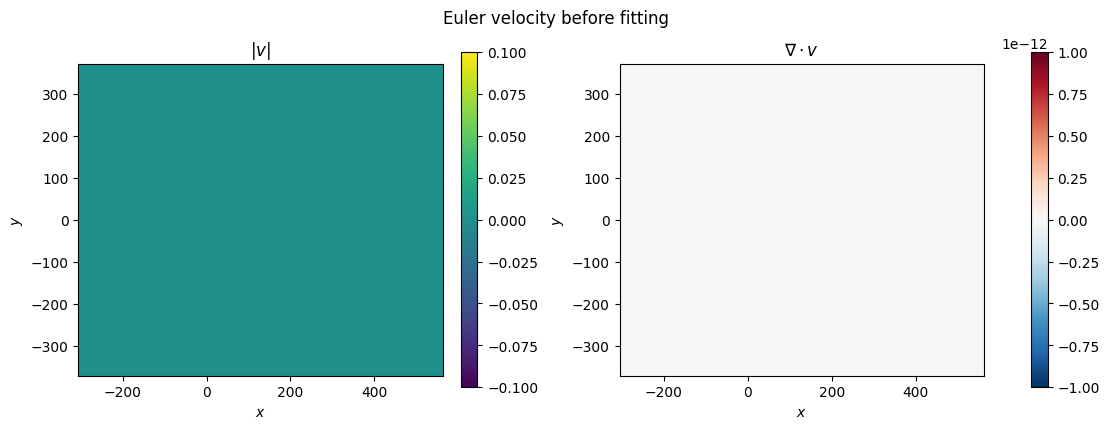

In [21]:
probe = EulerVelocity(
    num_fourier_features=32,
    length_scales=LSR,
    seed=1,
    device=device,
)

xx, yy = np.meshgrid(xs, ys, indexing="xy")
probe_xy = np.column_stack((xx.ravel(), yy.ravel())).astype(np.float32)
speed, div = velocity_snapshot(probe, probe_xy)
print(f"|v| max {speed.max():.4g}    |div v| max {np.max(np.abs(div)):.4g}")
plot_velocity(xs, ys, speed, div)



A velocity is not yet a map: we need to integrate it to trace the path of our coordinates as they get transported/advected from initial coordinates to their final ones (and/or, backwards from final to initial).  On this dataset that path has to rotate the curve whose normal points down back past vertical. The RestoringFlow class handles this integration, and optimises the loss to find a velocity field that gives the deformation we want.


In [22]:
flow = RestoringFlow(
    num_fourier_features=64,
    length_scales=LSR,
    n_steps=N_STEPS,
    depth_axis=1,
    seed=42,
    device=device,
)
history_flow = flow.fit(
    data,
    epochs=EPOCHS,
    lr=1e-1,
    patience=40,
    verbose=True,
)
print("frozen loss scales:", {k: f"{v:.3e}" for k, v in flow.scales.items()})
print("epochs kept:", len(history_flow))


flow: 100%|██████████| 250/250 [00:06<00:00, 38.59it/s, eq=0.00474, grad=0.000184, iq=0, total=0.00492] 

frozen loss scales: {'grad': '2.160e+00', 'eq': '2.562e-05', 'iq': '1.410e-05'}
epochs kept: 250


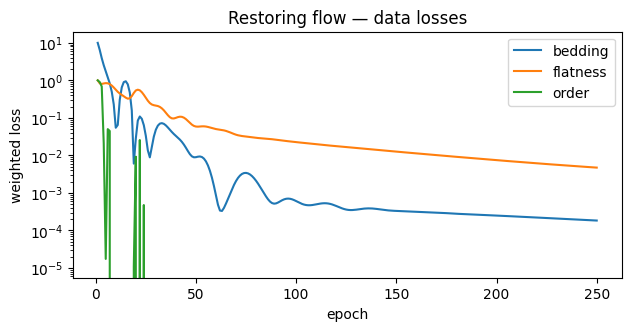

restoring flow
  restored-depth std   sparse 13.504    full traces 13.504
    horizon 0 (Younger horizon)  std φ = 15.871
    horizon 1 (Older horizon)  std φ = 11.136
  det J   min 0.9995   max 1.0001   mean |det J - 1| 7.482e-05   max |det J - 1| 4.545e-04   fraction det J < 0  0.000


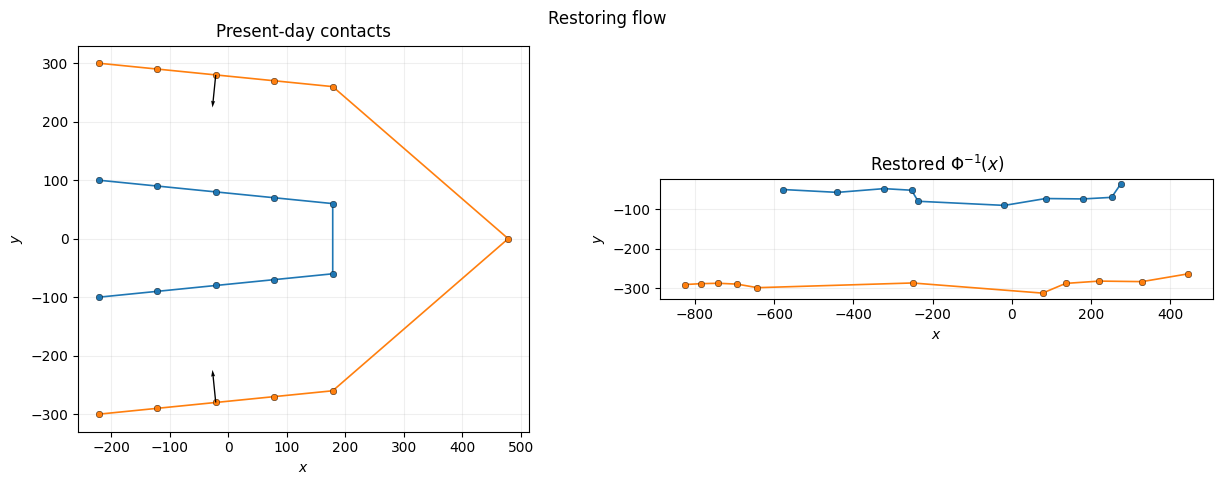

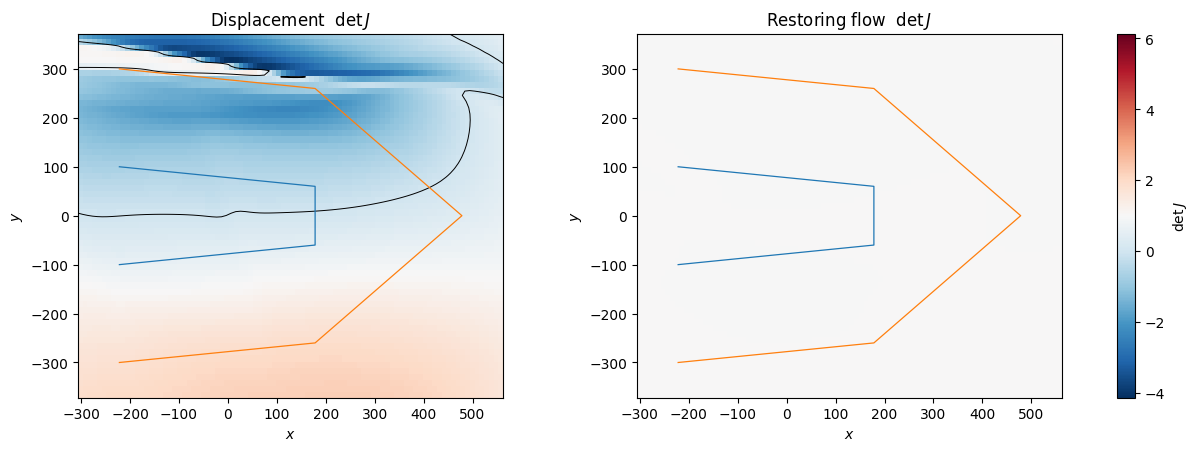

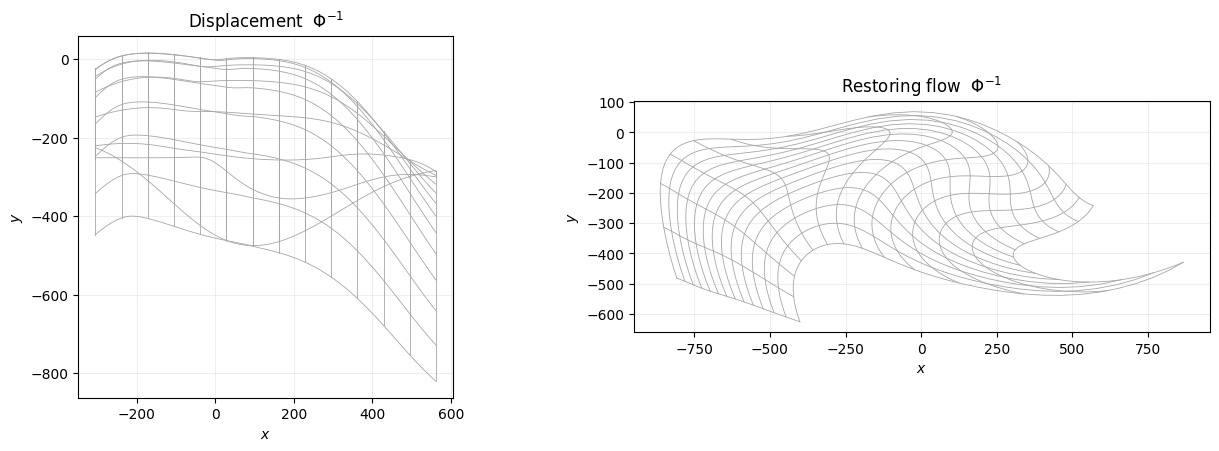

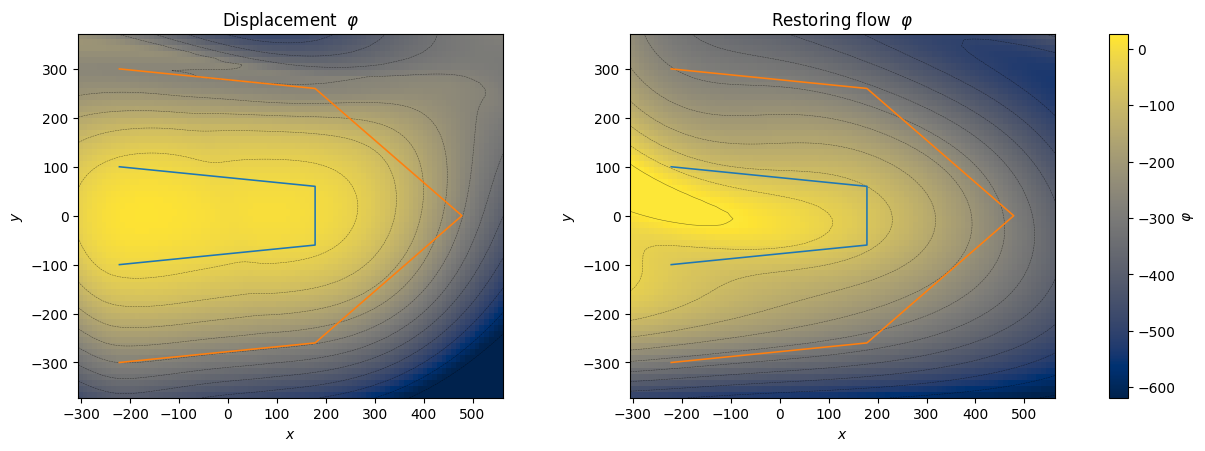

In [23]:
plot_history(history_flow, title="Restoring flow — data losses")
det_flow = summarise_restoration("restoring flow", flow.inverse_map, flow.jacobian, data, xs, ys)["det"]
plot_traces(data, flow.inverse_map, title="Restoring flow")
plot_determinants(
    xs,
    ys,
    [
        ("Displacement  $\det J$", det_disp),
        ("Restoring flow  $\det J$", det_flow),
    ],
    data,
)
plot_warps(
    xs,
    ys,
    [
        ("Displacement  $\Phi^{-1}$", field.inverse_map),
        ("Restoring flow  $\Phi^{-1}$", flow.inverse_map),
    ],
)
plot_scalar(
    xs,
    ys,
    [
        (r"Displacement  $\varphi$", field.inverse_map),
        (r"Restoring flow  $\varphi$", flow.inverse_map),
    ],
    data,
)


---------------

**Question 3**: The deformed grids above are the learned maps applied to a regular mesh. Which map is the more plausible deformation if area must be preserved? Is either fit unique, or do many maps agree on the observation points? If they do, what further constraint would shrink that set?

**Answer**: The integrated divergence-free field is the plausible one: its cells keep their area, the mesh does not tangle, and it can still rotate $e_y$ past vertical to match the downward normal. The direct displacement can match the same two normals and the same points while changing area and crossing itself. Neither solution is unique. Flatness only pins the vertical coordinate of the sample points up to a per-curve constant, and the normals only pin the Jacobian at two locations, so many area-preserving maps still interpolate the data. A further loss that keeps the spacing between the two curves constant along the flow — a thickness constraint — removes a large part of that null space.

---------------
